In [10]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout

Building LSTM
Training model...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0183
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0130
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0096
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0093
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0096
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0073
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0080
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0072
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0049
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0053
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033
Epoch 16/50
96/

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


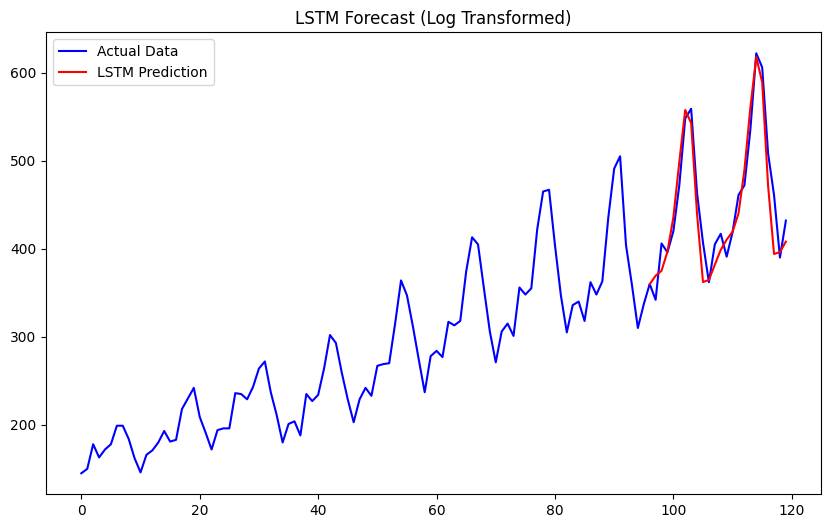


--- TEST SAMPLE #0 ---
Model Guessed: 359
Actual Number: 360
Off by:        0 passengers
Result: EXCELLENT


In [14]:
class AirlineModel:
    def __init__(self,file_path,look_back=24,test_size = 0.3):
        self.file_path = file_path
        self.look_back = look_back
        self.scaler = MinMaxScaler(feature_range=(0,1))
        self.model = None

    def load_and_prepare(self):
        df = pd.read_csv(self.file_path, usecols=[1])
        # STEP 1: Apply Log Transformation here
        data = np.log(df.values.astype('float32'))
        scaled_data = self.scaler.fit_transform(data)

        #Create the "Sliding Windows" (X and y) automatically
        dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=scaled_data[:-1],  # Everything except the very last point
        targets=scaled_data[self.look_back:],  # The "answers"
        sequence_length=self.look_back,
        batch_size=len(scaled_data)
       )

        # Pull X and y out of the helper
        for X, y in dataset:
            self.X, self.y = X.numpy(), y.numpy()

        # Split 80% for training / 20% for testing
        split = int(len(self.X) * 0.8)
        self.X_train, self.X_test = self.X[:split], self.X[split:]
        self.y_train, self.y_test = self.y[:split], self.y[split:]


# Add this inside your AirlineModel class
    def build_and_train(self, epochs=20):
        print("Building LSTM")
        self.model = Sequential([LSTM(100, activation='tanh',return_sequences=True, input_shape=(self.look_back, 1)),
             Dropout(0.1),
             LSTM(50,activation='tanh'),
             Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mse')

        print("Training model...")

        self.model.fit(self.X_train,
                      self.y_train,
                      epochs=epochs,
                      batch_size=1,
                      verbose=1)

    def evaluate(self):
        print("Predicting...")

        # Get predictions for the test set only
        test_pred = self.model.predict(self.X_test)

        # STEP 2: Inverse transform AND then apply np.exp()
        test_pred_real = np.exp(self.scaler.inverse_transform(test_pred))
        actual_all_real = np.exp(self.scaler.inverse_transform(self.y.reshape(-1, 1)))

        plt.figure(figsize=(10,6))

        plt.plot(actual_all_real, label="Actual Data",color="blue")

        start_point = len(self.X_train)
        plt.plot(range(start_point, len(actual_all_real)), test_pred_real,
             label="LSTM Prediction", color="red")
        plt.title("LSTM Forecast (Log Transformed)")
        plt.legend()
        plt.show()

    def rnn_prediction_demo(self, idx=0):
        guess_scaled = self.model.predict(self.X_test[idx:idx+1], verbose=0)

    # 2. Undo Scale AND Undo Log (np.exp)
        guess = np.exp(self.scaler.inverse_transform(guess_scaled))[0][0]
        real = np.exp(self.scaler.inverse_transform(self.y_test[idx].reshape(-1, 1)))[0][0]

        # 3. Calculate Error
        diff = abs(guess - real)

        # 4. Results
        print(f"\n--- TEST SAMPLE #{idx} ---")
        print(f"Model Guessed: {int(guess)}")
        print(f"Actual Number: {int(real)}")
        print(f"Off by:        {int(diff)} passengers")

        status = "EXCELLENT" if diff < 15 else "NEEDS IMPROVEMENT"
        print(f"Result: {status}")

DATA_URL = 'airline-passengers.csv'
rnn_project = AirlineModel(DATA_URL)
rnn_project.load_and_prepare()
rnn_project.build_and_train(epochs=50)
rnn_project.evaluate()
rnn_project.rnn_prediction_demo()


